In [10]:
from astropy.io import fits
import pandas as pd
import os

with fits.open('/kaggle/input/datasets/maanav0114/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
    harps_df = pd.DataFrame(data[1].data)

# Fix the big-endian to little-endian compiler issue
harps_df.to_csv('/kaggle/working/temp.csv', index=False)
del harps_df
harps_df = pd.DataFrame(pd.read_csv('/kaggle/working/temp.csv'))
os.remove('/kaggle/working/temp.csv')

# Rename HARPS columns to a unified naming scheme that matches HIRES
harps_df = harps_df.rename(columns={
    'main_id_simbad': 'star_name',
    'drs_bjd': 'bjd',
    'drs_ccf_rvc': 'rv',
    'drs_dvrms': 'rv_err',
    'drs_snr': 'snr',
    'exptime': 'exposure_time',
    'drs_version_number': 'drs_version'
})

harps_df.describe()

/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,tel_targ_alpha,tel_targ_delta,mjd_obs,exposure_time,ins_det1_tmmean,bjd,drs_version,snr,drs_berv,rv,...,pmdec_simbad,pmra_err_simbad,pmdec_err_simbad,pm_err_pa_simbad,Bmag_simbad,Vmag_simbad,Jmag_simbad,Hmag_simbad,Kmag_simbad,angDist_simbad
count,289843.000000,289843.000000,289843.000000,289843.000000,289843.000000,2.898430e+05,289842.000000,2.898430e+05,289843.000000,282294.000000,...,286314.000000,286160.000000,286160.000000,289843.000000,281625.000000,280194.000000,284186.000000,284110.000000,284175.000000,286766.000000
mean,177.214614,-32.856650,55673.352683,383.517457,0.472764,2.455674e+06,3.565870,-2.210453e+02,-0.812685,1255.906524,...,-29.278840,1.627111,1.514380,-339.983187,6.655004,5.954157,4.696480,4.346067,4.251171,0.884084
std,103.480554,26.652877,1720.035753,502.501236,0.086737,1.720036e+03,0.124186,1.994431e+05,14.992151,11342.374647,...,788.310609,5.155810,4.912895,3679.010556,3.255201,3.136321,2.886256,2.894555,2.876160,3.152134
min,0.000000,-88.818294,52901.354457,0.000000,-1.200000,2.452902e+06,3.500000,-1.073742e+08,-30.545979,-100008.611844,...,-5708.614000,0.007000,0.008000,-32768.000000,0.300000,0.010000,-3.000000,-3.730000,-4.050000,0.000000
25%,86.821208,-59.302156,54290.341733,40.001500,0.480000,2.454291e+06,3.500000,6.380000e+01,-12.327566,-19.753620,...,-214.278000,0.022000,0.020000,90.000000,4.220000,3.710000,2.840000,2.349000,2.237000,0.008873
50%,198.013271,-35.843611,55438.006770,135.505800,0.500000,2.455439e+06,3.500000,1.389500e+02,-0.670219,-1.018182,...,-14.942000,0.072000,0.065000,90.000000,6.150000,5.580000,4.750000,4.400000,4.298000,0.021803
75%,259.859883,-9.458250,56848.158706,600.001000,0.510000,2.456849e+06,3.500000,2.208500e+02,10.423184,19.441109,...,188.554000,0.161000,0.123000,90.000000,8.850000,8.130000,6.734000,6.397000,6.297000,0.181891
max,359.979458,29.830172,60094.086925,7199.995900,6.860000,2.460095e+06,3.800000,6.912500e+02,30.535827,182136.783699,...,10362.394000,33.000000,42.000000,32767.000000,20.290000,19.390000,17.610000,17.900000,17.970000,29.930780


In [11]:
from pathlib import Path
import pandas as pd
import os

# Define the directory containing the raw HIRES .vels files
directory = Path("/kaggle/input/datasets/maanav0114/harps-n-dataset/keck_vels/keck_vels/")  # This is where we processed the raw data

# Define column names for the 7 columns in each .vels file
columns = ['bjd', 'rv', 'rv_err', 's_index', 'h_index', 'photon_count', 'exposure_time']

# Initialize list to store rows
rows = []

# Process each .vels file
for filename in os.listdir(directory):
    if filename.endswith('.vels'):
        star_name = filename.replace('_KECK.vels', '')
        filepath = directory / filename

        with open(filepath, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                # Split by whitespace (handles variable spacing)
                values = line.split()
                if len(values) != 7:
                    continue  # Skip malformed lines

                # Create row with all 7 columns + star name
                row = {
                    'star_name': star_name,
                    'bjd': float(values[0]),
                    'rv': float(values[1]),
                    'rv_err': float(values[2]),
                    's_index': float(values[3]),
                    'h_index': float(values[4]),
                    'photon_count': int(values[5]),
                    'exposure_time': int(values[6])
                }
                rows.append(row)

# Create DataFrame with all columns preserved
hires_df = pd.DataFrame(rows)
hires_df.describe()

,bjd,rv,rv_err,s_index,h_index,photon_count,exposure_time
count,7.506200e+04,75062.000000,75062.000000,75062.000000,75061.000000,75062.000000,75062.000000
mean,2.454893e+06,-9.499061,1.880604,0.235462,-0.275377,59177.824798,168.207988
std,1.989164e+03,940.329217,3.903587,0.616451,0.474893,33258.099603,186.168712
min,2.450276e+06,-46649.640000,0.010000,-5.479300,-1.000000,181.000000,-1.000000
25%,2.453577e+06,-4.810000,1.200000,0.137100,-1.000000,41948.500000,34.000000
50%,2.455081e+06,0.000000,1.400000,0.160800,0.031090,50685.000000,88.000000
75%,2.456134e+06,4.510000,1.720000,0.260300,0.034100,78262.000000,236.000000
max,2.458919e+06,41546.190000,373.170000,68.860700,0.094840,616935.000000,2252.000000


In [12]:
harps_stars = []
for name in list(set(list(harps_df['star_name']))):
    name = name.split(" ")
    name = "".join(name)
    name = name.lower()

    harps_stars.append(name)

harps_stars[:10]

['skb2',
 'hd150177',
 '*omilib',
 'hd56341',
 'hd30447',
 'tyc6306-1822-1',
 '*nu.tel',
 'v*v594car',
 'hd224474',
 'hd80951']

In [13]:
# Combine HARPS and HIRES datasets into one combined dataset of their observations.

# Keep all quality-control columns from HARPS
cols_to_keep = ['star_name', 'bjd', 'rv', 'rv_err', 'snr', 'exposure_time', 'drs_version']
observations = harps_df[[col for col in cols_to_keep if col in harps_df.columns]].copy()

# HIRES-specific columns that HARPS doesn't have — fill with NaN for HARPS rows
for col in ['s_index', 'h_index', 'photon_count']:
    if col not in observations.columns:
        observations[col] = float('nan')

# Filter out stars already in HARPS dataset
cleaned_names = hires_df['star_name'].str.lower().str.replace(' ', '', regex=False)
harps_stars_set = set(harps_stars)
mask = ~cleaned_names.isin(harps_stars_set)

# Tag each row with its source instrument for provenance
observations['instrument'] = 'HARPS'
hires_subset = hires_df[mask].copy()
hires_subset['instrument'] = 'HIRES'

# HIRES doesn't have drs_version or snr — fill with NaN for HIRES rows
for col in ['drs_version', 'snr']:
    if col not in hires_subset.columns:
        hires_subset[col] = float('nan')

observations = pd.concat([observations, hires_subset], ignore_index=True)
observations = observations.dropna(subset=['bjd', 'rv', 'rv_err'])

observations

,star_name,bjd,rv,rv_err,snr,exposure_time,drs_version,s_index,h_index,photon_count,instrument
0,* tau Cet,2.452902e+06,-16.500015,1.006157,71.90,89.9959,3.8,NaN,NaN,NaN,HARPS
1,HD 207700,2.452937e+06,6.628923,4.996146,15.95,319.9959,3.5,NaN,NaN,NaN,HARPS
2,HD 191408,2.452937e+06,99981.724946,0.752430,60.50,179.9960,3.5,NaN,NaN,NaN,HARPS
3,HD 191408,2.452937e+06,99980.826365,0.708570,64.60,179.9962,3.5,NaN,NaN,NaN,HARPS
4,HD 191408,2.452937e+06,99981.194811,0.389267,117.00,179.9960,3.5,NaN,NaN,NaN,HARPS
...,...,...,...,...,...,...,...,...,...,...,...
346665,HD3411-02491-1,2.455190e+06,5.460000,0.390000,NaN,186.0000,NaN,0.8878,0.04082,29991.0,HIRES
346666,HIP17496,2.454779e+06,2.230000,1.340000,NaN,479.0000,NaN,0.6799,0.04097,30797.0,HIRES
346667,HIP17496,2.454780e+06,-2.160000,1.190000,NaN,182.0000,NaN,0.6907,0.04101,30708.0,HIRES
346668,HIP17496,2.455190e+06,0.000000,1.650000,NaN,192.0000,NaN,0.6121,0.04094,31749.0,HIRES


In [14]:
# Label each observation with 1 if corresponding star has exoplanets

import requests
import io
import re

# Query the NEA TAP service — use the `ps` table for confirmed planets only
tap_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
query = "SELECT DISTINCT hostname FROM ps WHERE pl_refname IS NOT NULL"
params = {'query': query, 'lang': 'ADQL', 'format': 'csv'}

print("Querying NEA TAP service (confirmed planets only)...")
response = requests.get(tap_url, params=params)
response.raise_for_status()

nea_df = pd.read_csv(io.StringIO(response.text))

# Normalize NEA hostnames: lowercase, remove spaces, strip whitespace
def normalize_name(name):
    if pd.isna(name):
        return ""
    return str(name).lower().replace(" ", "").strip()

nea_hosts = set(nea_df['hostname'].apply(normalize_name))

# Normalize the simbad names in our dataset
# Strip SIMBAD object-type prefixes (e.g. "* tau Cet" -> "tau Cet", "V* RR Lyr" -> "RR Lyr")
def strip_simbad_prefix(name):
    if pd.isna(name):
        return ""
    name = str(name).strip()
    name = re.sub(r'^\*\s+', '', name)              # "* tau Cet" -> "tau Cet"
    name = re.sub(r'^[A-Z]+[a-z]*\*\s+', '', name)  # "V* RR Lyr" -> "RR Lyr", "EM* ..." -> "..."
    name = name.strip()
    return name

observations['normalized_name'] = observations['star_name'].apply(
    lambda n: normalize_name(strip_simbad_prefix(n))
)

# Set has_exoplanets = 1 for stars in our nea_hosts set
observations['has_exoplanets'] = observations['normalized_name'].isin(nea_hosts).astype(int)

# Print summary
unique_stars = observations['star_name'].nunique()
star_labels = observations[['star_name', 'normalized_name', 'has_exoplanets']].drop_duplicates(subset=['star_name'])

num_positive = star_labels['has_exoplanets'].sum()
num_negative = len(star_labels) - num_positive

print(f"Total unique stars: {unique_stars}")
print(f"Number of stars labeled positive: {num_positive}")
print(f"Number of stars labeled negative: {num_negative}")

print("\nSample of positive matches (first 5):")
positive_matches = star_labels[star_labels['has_exoplanets'] == 1]['star_name'].head(5).tolist()
for p in positive_matches:
    print(p)

print("\nSample of unmatched stars (first 5):")
negative_matches = star_labels[star_labels['has_exoplanets'] == 0]['star_name'].head(5).tolist()
for n in negative_matches:
    print(n)

# Clean up
observations = observations.drop(columns=['normalized_name'])

print(f'{len(set(observations[observations["has_exoplanets"] == 1]["star_name"]))} stars with detectable planets.')

Querying NEA TAP service (confirmed planets only)...
Total unique stars: 7550
Number of stars labeled positive: 573
Number of stars labeled negative: 6977

Sample of positive matches (first 5):
* tau Cet
HD 177565
HD 189567
HD 219077
HD 221420

Sample of unmatched stars (first 5):
HD 207700
HD 191408
* del Pav
HD 207129
HD 211415
573 stars with detectable planets.


In [15]:
# Removing all stars with less than 20 observations

counts = observations.groupby('star_name')['star_name'].transform('size')
observations = observations[counts >= 20]

# Per-star mean subtraction for RV

observations['rv_mean'] = observations.groupby('star_name')['rv'].transform('mean')
observations['rv_centered'] = observations['rv'] - observations['rv_mean']

# Verification

for star in observations['star_name'].unique()[:3]:
    star_data = observations[observations['star_name'] == star]
    print(f"{star}: original mean = {star_data['rv'].mean():.2f}, centered mean = {star_data['rv_centered'].mean():.6f}")

* tau Cet: original mean = -8.28, centered mean = 0.000000
HD 207700: original mean = 6.61, centered mean = -0.000000
HD 191408: original mean = 18880.00, centered mean = 0.000000


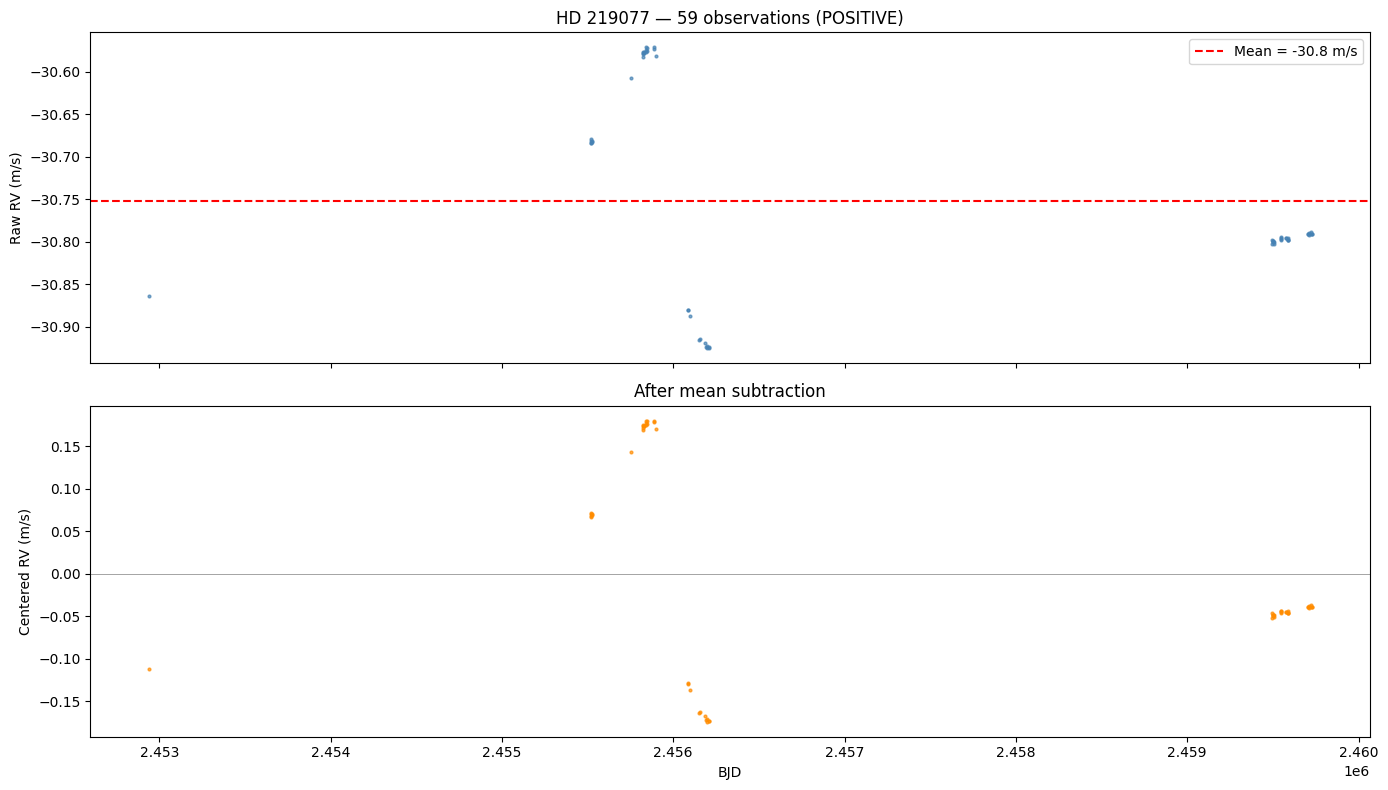


Positive example: HD 219077 (59 obs, mean=-30.8 m/s)
Negative example: HD 207700 (38 obs, mean=6.6 m/s)


In [21]:
import matplotlib.pyplot as plt

observations['rv_mean'] = observations.groupby('star_name')['rv'].transform('mean')
observations['rv_centered'] = observations['rv'] - observations['rv_mean']

positive_stars = observations[observations['has_exoplanets'] == 1]['star_name'].unique()
sample_star = positive_stars[3]
star_data = observations[observations['star_name'] == sample_star].sort_values('bjd')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.scatter(star_data['bjd'], star_data['rv'], s=4, alpha=0.7, c='steelblue')
ax1.axhline(y=star_data['rv_mean'].iloc[0], color='red', linestyle='--', label=f"Mean = {star_data['rv_mean'].iloc[0]:.1f} m/s")
ax1.set_ylabel('Raw RV (m/s)')
ax1.set_title(f'{sample_star} — {len(star_data)} observations (POSITIVE)')
ax1.legend()

ax2.scatter(star_data['bjd'], star_data['rv_centered'], s=4, alpha=0.7, c='darkorange')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.set_xlabel('BJD')
ax2.set_ylabel('Centered RV (m/s)')
ax2.set_title('After mean subtraction')

plt.tight_layout()
plt.show()

negative_stars = observations[observations['has_exoplanets'] == 0]['star_name'].unique()
neg_star = negative_stars[0]
neg_data = observations[observations['star_name'] == neg_star].sort_values('bjd')
print(f'\nPositive example: {sample_star} ({len(star_data)} obs, mean={star_data["rv_mean"].iloc[0]:.1f} m/s)')
print(f'Negative example: {neg_star} ({len(neg_data)} obs, mean={neg_data["rv_mean"].iloc[0]:.1f} m/s)')

In [17]:
# Quality-flag filtering: remove known-bad observations

n_before = len(observations)

# Filter 1: zero exposure time (no light collected — observation is invalid)
if 'exposure_time' in observations.columns:
    bad_exptime = observations['exposure_time'] == 0.0
    print(f'Zero exposure_time observations: {bad_exptime.sum()}')
    observations = observations[~bad_exptime]

# Filter 2: sentinel SNR values for HARPS (e.g. -1.07e8 indicates a failed CCF fit)
if 'snr' in observations.columns:
    bad_snr = observations['snr'] < 0
    print(f'Negative/invalid SNR observations (HARPS): {bad_snr.sum()}')
    observations = observations[~bad_snr]

# Filter 3: sentinel S-index values for HIRES (-1.0 means not measured)
# NOTE: We do NOT drop these rows — -1.0 is valid (just pre-2004 data)
# Instead, replace -1.0 with NaN so they don't corrupt statistics
if 's_index' in observations.columns:
    sentinel_count = (observations['s_index'] == -1.0).sum()
    print(f'Sentinel S-index values (-1.0, not measured): {sentinel_count}')
    observations.loc[observations['s_index'] == -1.0, 's_index'] = float('nan')

if 'h_index' in observations.columns:
    sentinel_h = (observations['h_index'] == -1.0).sum()
    print(f'Sentinel H-index values (-1.0, not measured): {sentinel_h}')
    observations.loc[observations['h_index'] == -1.0, 'h_index'] = float('nan')

# Filter 4: low photon count for HIRES (extremely low signal observations)
if 'photon_count' in observations.columns:
    low_photon = observations['photon_count'] < 1000
    print(f'Very low photon count observations (<1000, HIRES): {low_photon.sum()}')
    observations = observations[~low_photon]

n_after = len(observations)
print(f'\nObservations: {n_before} → {n_after} (removed {n_before - n_after})')
print(f'Stars remaining: {observations["star_name"].nunique()}')
print(f'Positive stars: {observations[observations["has_exoplanets"] == 1]["star_name"].nunique()}')

Zero exposure_time observations: 1563
Negative/invalid SNR observations (HARPS): 0
Sentinel S-index values (-1.0, not measured): 3669
Sentinel H-index values (-1.0, not measured): 14683
Very low photon count observations (<1000, HIRES): 59

Observations: 307703 → 306081 (removed 1622)
Stars remaining: 2479
Positive stars: 419


In [18]:
# Saving dataframe to pickle file

observations = observations.drop(columns=['rv_mean'], errors='ignore')

observations.to_pickle('/kaggle/working/observations.pkl')
print(f'{observations[observations["has_exoplanets"] == 1]["star_name"].nunique()} stars with detectable planets.')
print(f'Dataset shape: {observations.shape}')
print(f'Columns: {list(observations.columns)}')

419 stars with detectable planets.
Dataset shape: (306081, 13)
Columns: ['star_name', 'bjd', 'rv', 'rv_err', 'snr', 'exposure_time', 'drs_version', 's_index', 'h_index', 'photon_count', 'instrument', 'has_exoplanets', 'rv_centered']
